In [1]:
import sys
sys.path.append('../')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
import optuna
import random
import os
import warnings
from src.mypackage.data_preparation import prepare_lightgbm_data

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

In [2]:
df = pd.read_csv("../data/raw/PJME_hourly.csv")
# data = prepare_lightgbm_data(df, lags=[2, 24, 24*7], pred_len=24*7, shift=24*7//8)
data = prepare_lightgbm_data(df, lags=[2, 24, 24*7], pred_len=1, shift=1)

In [3]:
# X_train, y_train, X_test, y_test = data['X_train'].iloc[:, 1:], data['y_train'], data['X_test'].iloc[:, 1:], data['y_test']
# X_train, X_valid = X_train[:int(len(X_train)*0.8)], X_train[int(len(X_train)*0.8):]
# y_train, y_valid = y_train[:int(len(y_train)*0.8)], y_train[int(len(y_train)*0.8):]
X_train, y_train, X_test, y_test = data['X_train'].iloc[:, 1:], data['y_train'].reshape(-1), data['X_test'].iloc[:, 1:], data['y_test'].reshape(-1)
X_train, X_valid = X_train[:-24*365], X_train[-24*365:]
y_train, y_valid = y_train[:-24*365], y_train[-24*365:]


def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "verbosity": -1,
        "bagging_freq": 1,
        "feature_pre_filter": False,
        "seed": 42,

        # 探索対象
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 100),
        "max_depth": trial.suggest_int("max_depth", -1, 20),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 10.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 10.0),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
    }

    callbacks = [
        lgb.early_stopping(stopping_rounds=10, verbose=False),
        # lgb.log_evaluation(period=100)
    ]

    ds_train = lgb.Dataset(data=X_train, label=y_train)
    ds_valid = lgb.Dataset(data=X_valid, label=y_valid, reference=ds_train)
    model = lgb.train(params, ds_train, num_boost_round=1000, 
                      valid_sets=[ds_valid], callbacks=callbacks)
    best_rmse = model.best_score["valid_0"]["rmse"]
    best_iteration = model.best_iteration
    trial.set_user_attr("best_iteration", best_iteration)
    return best_rmse   

In [4]:
sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction="minimize", sampler=sampler)
study.optimize(objective, n_trials=50)
print(study.best_params) 

[I 2026-07-11 15:43:24,466] A new study created in memory with name: no-name-2b5d9b06-cd91-47d7-bc72-678f8f695e35
[I 2026-07-11 15:43:43,099] Trial 0 finished with value: 273.23838219255725 and parameters: {'learning_rate': 0.043284502212938815, 'num_leaves': 287, 'min_data_in_leaf': 76, 'max_depth': 12, 'lambda_l1': 1.5601864044243652, 'lambda_l2': 1.5599452033620265, 'feature_fraction': 0.5290418060840998, 'bagging_fraction': 0.9330880728874675}. Best is trial 0 with value: 273.23838219255725.
[I 2026-07-11 15:43:52,161] Trial 1 finished with value: 271.7069329577125 and parameters: {'learning_rate': 0.10502105436744279, 'num_leaves': 218, 'min_data_in_leaf': 11, 'max_depth': 20, 'lambda_l1': 8.324426408004218, 'lambda_l2': 2.1233911067827616, 'feature_fraction': 0.5909124836035503, 'bagging_fraction': 0.5917022549267169}. Best is trial 1 with value: 271.7069329577125.
[I 2026-07-11 15:43:59,269] Trial 2 finished with value: 300.70980583778993 and parameters: {'learning_rate': 0.0328

{'learning_rate': 0.031801890790700754, 'num_leaves': 178, 'min_data_in_leaf': 33, 'max_depth': 15, 'lambda_l1': 4.126807888453963, 'lambda_l2': 3.56930661602198, 'feature_fraction': 0.9124723863284004, 'bagging_fraction': 0.8106746126819561}


In [37]:
# 再学習
ds_train = lgb.Dataset(data=data["X_train"].iloc[:, 1:], label=data["y_train"].reshape(-1))
model = lgb.train(study.best_params, ds_train, num_boost_round= study.best_trial.user_attrs["best_iteration"])
model.save_model("../models/lightgbm_best_model.txt")

In [40]:
# モデルの読み込み
model = lgb.Booster(model_file="../models/lightgbm_best_model.txt")

In [41]:
def lightgbm_forecast(model, data, pred_len):
    idx = len(data["X_train"])
    predict_df = pd.concat([data["X_train"], data["X_test"]], axis=0, ignore_index=True)
    q, r = divmod(len(data["X_test"]), pred_len)
    y_preds = []
    if r != 0:
        q += 1
    for i in range(q):
        if i == q - 1 and r != 0:
            pred_len = r
        for j in range(pred_len):
            y_pred = model.predict(predict_df.iloc[[idx], 1:])
            y_preds.append(y_pred)
            if i == q-1 and j == pred_len - 1:
                break
            idx += 1
            fill_predict_df_by_pred(predict_df, y_pred, idx, lags=[2, 24, 24*7])
        fill_predict_df_by_trues(predict_df, data["y_test"][i * pred_len:i * pred_len + pred_len].reshape(-1), 
                                 idx, lags=[2, 24, 24*7], pred_len=pred_len)
    return np.array(y_preds).reshape(-1)

def fill_predict_df_by_pred(predict_df, y_pred, idx, lags):
    predict_df.loc[predict_df.index[idx], "lag_1"] = y_pred

    for lag in lags:
        predict_df.loc[predict_df.index[idx], f"lag_{lag}"] = predict_df.loc[predict_df.index[idx-lag], "lag_1"]

    predict_df.loc[predict_df.index[idx], "diff_1h"] = (
        predict_df.iloc[idx]["lag_1"]
        - predict_df.iloc[idx-1]["lag_1"]
    )
    predict_df.loc[predict_df.index[idx], "roll_mean_day"] = (
        predict_df.loc[
            predict_df.index[idx-23:idx+1],
            "lag_1"
        ].mean()
    )
    predict_df.loc[predict_df.index[idx], "roll_std_month"] = (
        predict_df.loc[
            predict_df.index[idx-24*30+1:idx+1],
            "lag_1"
        ].std()
    )

def fill_predict_df_by_trues(predict_df, y_trues, idx, lags, pred_len):
    start = idx - pred_len + 1
    end = idx
    rows = predict_df.index[start:end+1]

    predict_df.loc[rows, "lag_1"] = y_trues

    for lag in lags:
        predict_df.loc[rows, f"lag_{lag}"] = predict_df.loc[predict_df.index[start-lag:end-lag+1], "lag_1"].values

    predict_df.loc[rows, "diff_1h"] = (
        predict_df.loc[rows, "lag_1"].values
        - predict_df.loc[
            predict_df.index[start-1:end],
            "lag_1"
        ].values
    )

    for i in range(start, end+1):
        predict_df.loc[predict_df.index[i], "roll_mean_day"] = (
            predict_df.loc[
                predict_df.index[i-23:i+1],
                "lag_1"
            ].mean()
        )
        predict_df.loc[predict_df.index[i], "roll_std_month"] = (
            predict_df.loc[
                predict_df.index[i-24*30+1:i+1],
                "lag_1"
            ].std()
        )

In [42]:
y_pred_24h = lightgbm_forecast(model, data, pred_len=24)
y_pred_1week = lightgbm_forecast(model, data, pred_len=24*7)
y_pred_1month = lightgbm_forecast(model, data, pred_len=24*30)
y_pred_1year = lightgbm_forecast(model, data, pred_len=24*365)

In [43]:
y_test = data["y_test"].reshape(-1)[np.isnan(data["y_test"].reshape(-1)) == False]

In [44]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

mae = mean_absolute_error(y_test, y_pred_24h[:len(y_test)])
rmse = root_mean_squared_error(y_test, y_pred_24h[:len(y_test)])
mape = mean_absolute_percentage_error(y_test, y_pred_24h[:len(y_test)])

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 1794.36
RMSE: 2507.95
MAPE: 5.54%


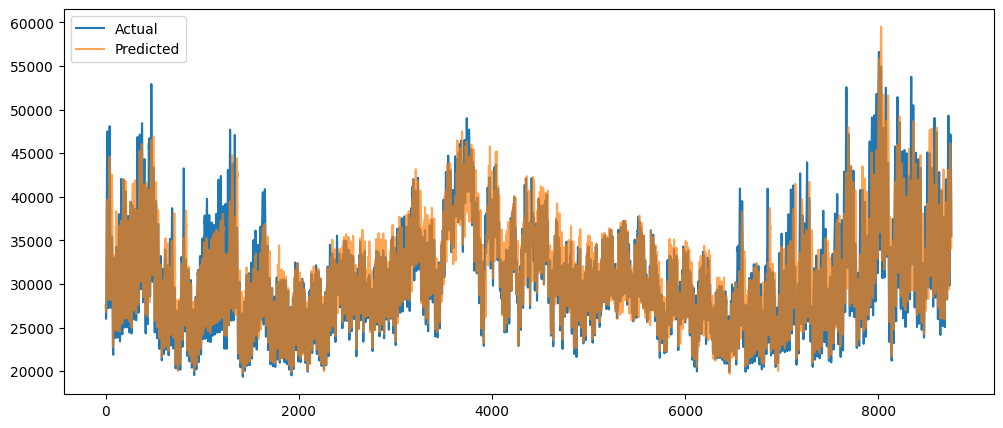

In [45]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_24h[:len(y_test)], label="Predicted", alpha=0.7)
plt.legend()
plt.show()

In [46]:
mae = mean_absolute_error(y_test, y_pred_1week[:len(y_test)])
rmse = root_mean_squared_error(y_test, y_pred_1week[:len(y_test)])
mape = mean_absolute_percentage_error(y_test, y_pred_1week[:len(y_test)])

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 2845.72
RMSE: 3932.56
MAPE: 8.81%


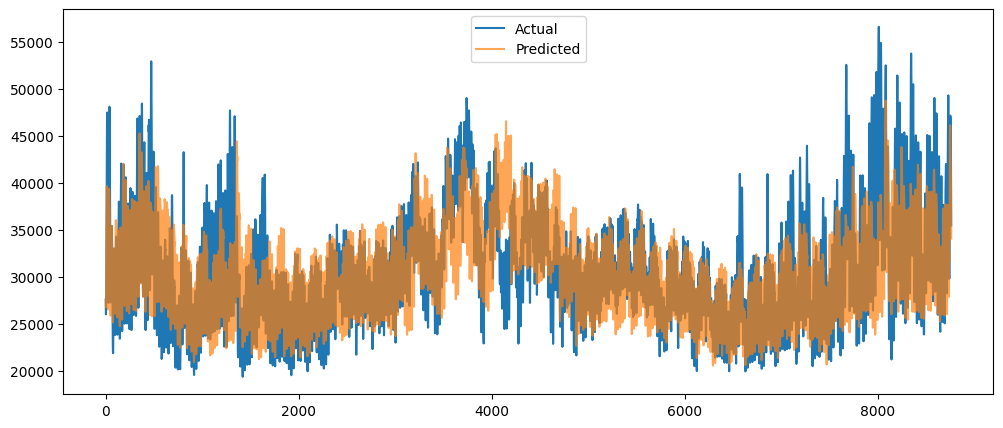

In [47]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_1week[:len(y_test)], label="Predicted", alpha=0.7)
plt.legend()
plt.show()

In [48]:
mae = mean_absolute_error(y_test, y_pred_1month[:len(y_test)])
rmse = root_mean_squared_error(y_test, y_pred_1month[:len(y_test)])
mape = mean_absolute_percentage_error(y_test, y_pred_1month[:len(y_test)])

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 3121.12
RMSE: 4176.23
MAPE: 9.53%


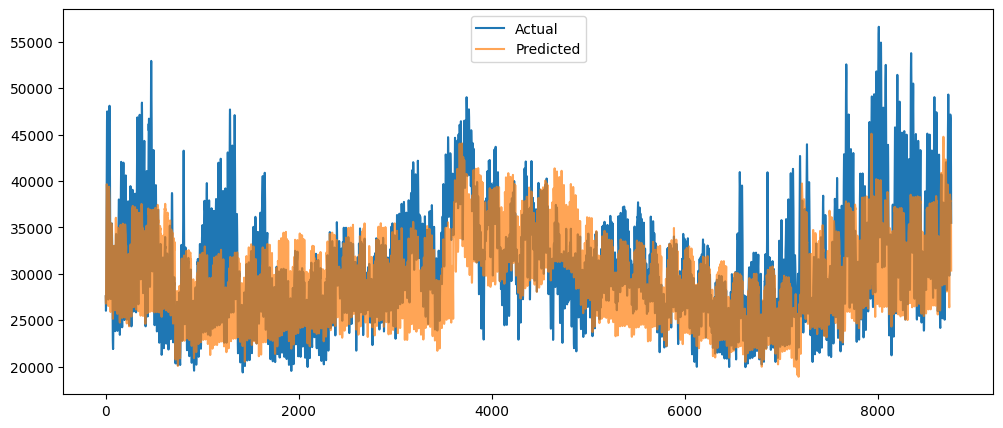

In [49]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_1month[:len(y_test)], label="Predicted", alpha=0.7)
plt.legend()
plt.show()

In [50]:
mae = mean_absolute_error(y_test, y_pred_1year[:len(y_test)])
rmse = root_mean_squared_error(y_test, y_pred_1year[:len(y_test)])
mape = mean_absolute_percentage_error(y_test, y_pred_1year[:len(y_test)])

print(f"MAE: {mae:.2f}\nRMSE: {rmse:.2f}\nMAPE: {mape*100:.2f}%")

MAE: 3442.30
RMSE: 4861.59
MAPE: 10.14%


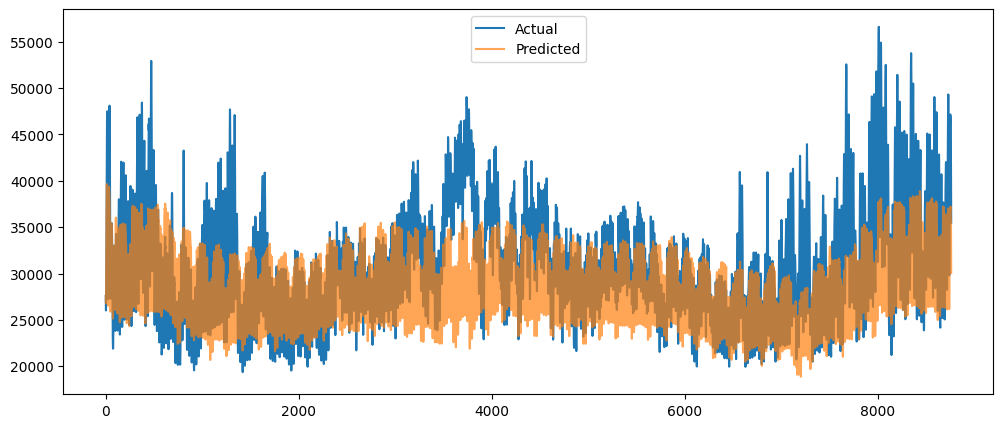

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual")
plt.plot(y_pred_1year[:len(y_test)], label="Predicted", alpha=0.7)
plt.legend()
plt.show()